# Jasmin Experiments

Notebook orchestration only. Shared implementation lives in `src/`.

ROADMAP: 
Baseline PatchCore          0.40  (done)
+ multi-view fusion         ~0.45 (1 hour)
+ DINOv2 backbone           ~0.55 (1 day)
+ supervised patch MLP      ~0.75-0.85 (2-3 days)
+ ensemble + TTA            ~0.80+ (polish)

Semi-supervision improvements:
- Feature normalization — the MLP gets raw backbone features without normalizing by the training distribution. This is critical for MLP stability and performance. Should subtract the mean and divide by std of normal patch features before training.

- Focal loss instead of fixed pos_weight — with ~1% anomalous patches, a fixed weight is fragile. Focal loss dynamically focuses on hard examples.

- Data augmentation on anomalous patches — 235 examples is very few. Flipping/rotating anomalous patches during training effectively multiplies the anomaly dataset.

- The deepest issue — combining with PatchCore: The MLP sees raw features with no "normality reference". The most principled approach is to also feed PatchCore's k-NN distances as input features. The MLP then has both:
-- How far this patch is from the normal distribution (PatchCore)
-- What the patch looks like (backbone features)
- Hard negative mining — after first training pass, find the hardest normal patches (high MLP score but label=0) and oversample them in subsequent epochs.

The better architecture: instead of training from scratch, use PatchCore scores as starting point and train the MLP to calibrate/refine them using the labeled anomalies. Much less data needed.

In [4]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.common.config import load_config
from src.common.data import SpacepressoDataModule
from src.common.evaluation import evaluate_predictions
from src.common.paths import resolve_path
from src.common.seed import set_seed
from src.common.submission import SubmissionWriter, validate_submission
from src.common.training import ExperimentRunner
from src.common.validation import make_validation_split
from src.common.visualization import show_predictions
from src.methods import get_method_class

In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("PyTorch:", torch.__version__)

CUDA available: True
Device: NVIDIA GeForce RTX 4060 Ti
PyTorch: 2.3.1


In [ ]:
# patchcore
#config = load_config(ROOT / "configs/patchcore_lite/jasmin_test.yaml")
# patchcore DINOv2
#config = load_config(ROOT / "configs/patchcore_dinov2/jasmin_dinov2.yaml")
# supervised MLP
config = load_config(ROOT / "configs/supervised_patch_mlp/jasmin_mlp.yaml")
# student teacher
#config = load_config(ROOT / "configs/student_teacher/jasmin_st.yaml")

set_seed(config.get("seed", 42))

local_data = ROOT / "data" / "spacepresso"
if local_data.exists():
    config["data"]["root"] = str(local_data)
config["data"]["load_images"] = False

# --- Toggles ---
NO_BACKGROUND          = True
NO_BACKGROUND_TRAINING = True
VIEW_WISE              = True
MULTI_VIEW_FUSION      = True
MULTI_VIEW_CONSISTENCY = True
BG_DILATION            = 16
BG_THRESHOLD           = 0.20
BG_THRESHOLD_PER_CLASS = {
    "class_01": 0.40,
    "class_02": 0.30,
    "class_08": 0.40,
}

def get_bg_threshold(class_name, view_id=None):
    if view_id and (class_name, view_id) in BG_THRESHOLD_PER_CLASS:
        return BG_THRESHOLD_PER_CLASS[(class_name, view_id)]
    return BG_THRESHOLD_PER_CLASS.get(class_name, BG_THRESHOLD)

if NO_BACKGROUND_TRAINING:
    config["method"]["no_background"]          = True
    config["method"]["bg_threshold"]           = BG_THRESHOLD
    config["method"]["bg_dilation"]            = BG_DILATION
    config["method"]["bg_threshold_per_class"] = BG_THRESHOLD_PER_CLASS

if VIEW_WISE:
    config["method"]["view_wise"] = True

dm = SpacepressoDataModule(**config["data"])
train_good      = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test            = dm.load_test()
print({"train_good": len(train_good), "train_anomalies": len(train_anomalies), "test": len(test)})

DEV_CLASSES = None  # set to e.g. ["class_03"] for fast iteration
if DEV_CLASSES:
    train_good      = [s for s in train_good      if s.class_name in DEV_CLASSES]
    train_anomalies = [s for s in train_anomalies if s.class_name in DEV_CLASSES]
    test            = [s for s in test            if s.class_name in DEV_CLASSES]
    print(f"Filtered to {DEV_CLASSES}: {len(train_good)} train, {len(train_anomalies)} anomalies, {len(test)} test")

# --- Anomaly train/val split (so we can evaluate locally without cheating) ---
# Set to 0.0 for the final Kaggle submission to train on all anomalies.
VAL_ANOMALY_FRACTION = 0.2

import random as _rng
_rng.seed(config.get("seed", 42))
_shuffled = _rng.sample(train_anomalies, len(train_anomalies))
_n_val = max(1, int(len(_shuffled) * VAL_ANOMALY_FRACTION))
train_anomalies_val = _shuffled[:_n_val]   # held out — never seen during training
train_anomalies_fit = _shuffled[_n_val:]   # used for training
print(f"Anomaly split: {len(train_anomalies_fit)} fit / {len(train_anomalies_val)} val")

## Background extraction

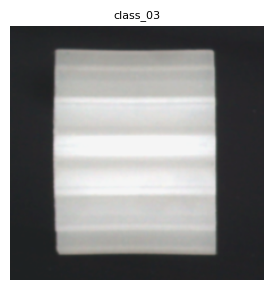

In [7]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np

classes = sorted({s.class_name for s in train_good})
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
if len(classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    sample = next(s for s in train_good if s.class_name == cls)
    img = np.array(PILImage.open(sample.image_path).convert("RGB"))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

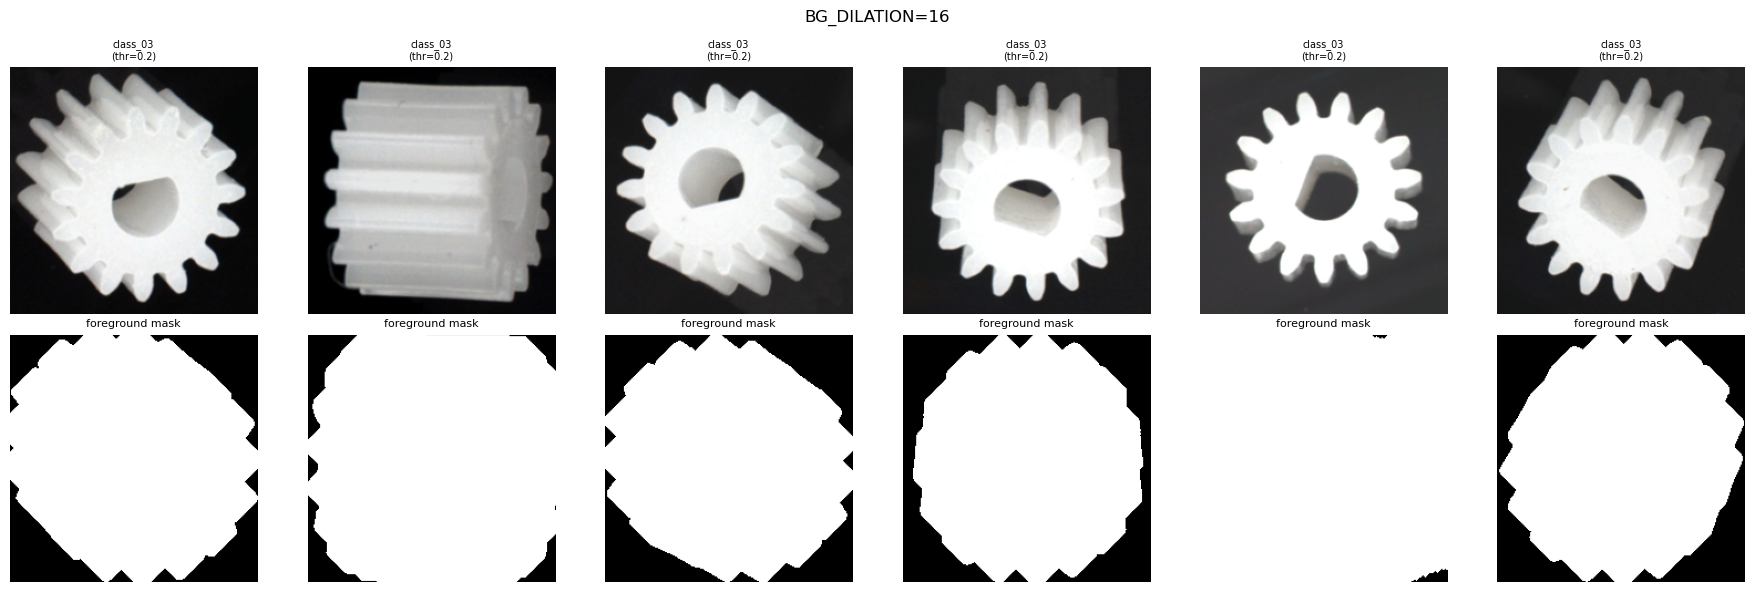

In [8]:
# Sanity check: visualize foreground masks on a few training images
if NO_BACKGROUND:
    import random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate

    def _preview_foreground_mask(image_np, threshold, dilation):
        gray = image_np.mean(axis=2)
        fg = binary_fill_holes(gray > threshold)
        if dilation > 0:
            fg = _bdilate(fg, iterations=dilation)
        return fg.astype(np.float32)

    samples = random.sample(train_good, 6)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for col, sample in enumerate(samples):
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((config["data"]["image_size"], config["data"]["image_size"]))) / 255.0
        threshold = get_bg_threshold(sample.class_name)
        mask = _preview_foreground_mask(img, threshold, BG_DILATION)
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"{sample.class_name}\n(thr={threshold})", fontsize=7)
        axes[0, col].axis("off")
        axes[1, col].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title("foreground mask", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(f"BG_DILATION={BG_DILATION}")
    plt.tight_layout()
    plt.show()

## Training

In [ ]:
if train_good and test:
    Method = get_method_class(config["method"]["name"])
    runner = ExperimentRunner(Method(config), config)
    runner.fit(train_good + train_anomalies_fit)  # val anomalies withheld
    predictions = runner.predict(test)
    show_predictions(test, predictions, n=3)
else:
    predictions = {}
    print("Dataset is empty or not found. Update config['data']['root'] before running.")

In [10]:
#runner.method.plot_training_history()

In [11]:
# Background suppression: zero out outer black background in each prediction map
if NO_BACKGROUND and predictions:
    from PIL import Image as PILImage
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
    import numpy as np

    image_size = config["data"]["image_size"]
    id_to_sample = {s.image_id: s for s in test}

    for img_id, pred in predictions.items():
        sample = id_to_sample[img_id]
        threshold = get_bg_threshold(sample.class_name)
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
        fg = binary_fill_holes(img.mean(axis=2) > threshold)
        if BG_DILATION > 0:
            fg = _bdilate(fg, iterations=BG_DILATION)
        predictions[img_id] = pred * fg.astype(np.float32)

    print("Background suppression applied.")

Background suppression applied.


In [12]:
import numpy as np
from collections import defaultdict

# Build sample→views map from test set
sample_to_views = defaultdict(list)
for s in test:
    sample_to_views[s.sample_id].append(s.image_id)

# --- Multi-view fusion: propagate max score across all 5 views ---
if MULTI_VIEW_FUSION and predictions:
    n_boosted = 0
    for image_ids in sample_to_views.values():
        maps = [predictions[iid] for iid in image_ids if iid in predictions]
        if not maps:
            continue
        sample_max = max(float(m.max()) for m in maps)
        for iid in image_ids:
            if iid not in predictions:
                continue
            view_max = float(predictions[iid].max())
            if view_max < sample_max - 1e-6:
                scale = sample_max / max(view_max, 1e-6)
                predictions[iid] = np.clip(predictions[iid] * scale, 0.0, 1.0).astype(predictions[iid].dtype)
                n_boosted += 1
    print(f"Multi-view fusion: {n_boosted} views boosted out of {len(predictions)} total")

# --- Multi-view consistency: boost samples where views strongly disagree ---
# High disagreement (one view much higher than others) = likely true defect
if MULTI_VIEW_CONSISTENCY and predictions:
    CONSISTENCY_ALPHA = 0.5  # how strongly to apply the boost (tune between 0.2 and 1.0)
    n_boosted = 0
    for image_ids in sample_to_views.values():
        present = [iid for iid in image_ids if iid in predictions]
        if len(present) < 2:
            continue
        scores = [float(predictions[iid].max()) for iid in present]
        s_max  = max(scores)
        s_mean = float(np.mean(scores))
        if s_mean < 1e-6:
            continue
        # disagreement ratio: how much the best view stands out above average
        disagreement = (s_max - s_mean) / (s_max + 1e-6)
        boost = 1.0 + CONSISTENCY_ALPHA * disagreement
        for iid in present:
            predictions[iid] = np.clip(predictions[iid] * boost, 0.0, 1.0).astype(predictions[iid].dtype)
            n_boosted += 1
    print(f"Multi-view consistency: boost applied to {n_boosted} views (alpha={CONSISTENCY_ALPHA})")

Multi-view fusion: 631 views boosted out of 790 total
Multi-view consistency: boost applied to 790 views (alpha=0.5)


## Validation + File saving

In [13]:
# Cross-view feature infrastructure (used by the supervised patch MLP in the next roadmap step)
# Builds a lookup: sample_id → {view_id: image_id} for both train and test sets
from collections import defaultdict

def build_sample_view_index(samples):
    """Returns {sample_id: {view_id: image_id}} for quick cross-view lookup."""
    index = defaultdict(dict)
    for s in samples:
        index[s.sample_id][s.view_id] = s.image_id
    return dict(index)

train_sample_index = build_sample_view_index(train_good + train_anomalies)
test_sample_index  = build_sample_view_index(test)

# Sanity check: how many samples have all 5 views?
full_samples = sum(1 for v in test_sample_index.values() if len(v) == 5)
print(f"Test samples with all 5 views: {full_samples} / {len(test_sample_index)}")
print(f"Train samples with all 5 views: {sum(1 for v in train_sample_index.values() if len(v) == 5)} / {len(train_sample_index)}")

Test samples with all 5 views: 158 / 158
Train samples with all 5 views: 508 / 508


In [ ]:
# Validation: held-out anomalies + sample of good images (no training data used)
if predictions:
    import random as _random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from src.common.evaluation import load_sample_mask

    N_GOOD_VAL = 200
    good_sample = _random.sample(train_good, min(N_GOOD_VAL, len(train_good)))
    val_samples = train_anomalies_val + good_sample   # only held-out anomalies
    val_predictions = runner.predict(val_samples)

    if NO_BACKGROUND:
        from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
        id_to_sample = {s.image_id: s for s in val_samples}
        image_size = config["data"]["image_size"]
        for img_id, pred in val_predictions.items():
            s = id_to_sample[img_id]
            threshold = get_bg_threshold(s.class_name)
            img = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
            fg = binary_fill_holes(img.mean(axis=2) > threshold)
            if BG_DILATION > 0:
                fg = _bdilate(fg, iterations=BG_DILATION)
            val_predictions[img_id] = pred * fg.astype(np.float32)

    metrics = evaluate_predictions(val_samples, val_predictions).as_dict()
    print(f"Evaluated on {len(train_anomalies_val)} held-out anomalies + {len(good_sample)} good images")
    print(f"Pixel AP:    {metrics['pixel_ap']:.4f}")
    print(f"Image AP:    {metrics['image_ap']:.4f}")
    print(f"Pixel AUROC: {metrics['pixel_auroc']:.4f}")

    # Visualize 2 held-out anomalous samples per class
    image_size = config["data"]["image_size"]
    grouped = {}
    for s in train_anomalies_val:
        grouped.setdefault(s.class_name, []).append(s)

    if grouped:
        n_classes = len(grouped)
        fig, axes = plt.subplots(n_classes, 6, figsize=(18, 3 * n_classes), squeeze=False)
        for row, (cls, samples) in enumerate(sorted(grouped.items())):
            picks = _random.sample(samples, min(2, len(samples)))
            for col_offset, s in enumerate(picks):
                img  = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size)))
                gt   = load_sample_mask(s, (image_size, image_size))
                pred = val_predictions[s.image_id]
                c = col_offset * 3
                axes[row, c].imshow(img)
                axes[row, c].set_title(f"{cls}" if col_offset == 0 else "", fontsize=7)
                axes[row, c].axis("off")
                axes[row, c+1].imshow(gt,   cmap="hot", vmin=0, vmax=1)
                axes[row, c+1].set_title("ground truth" if row == 0 else "", fontsize=7)
                axes[row, c+1].axis("off")
                axes[row, c+2].imshow(pred, cmap="hot", vmin=0, vmax=1)
                axes[row, c+2].set_title("prediction" if row == 0 else "", fontsize=7)
                axes[row, c+2].axis("off")
        plt.suptitle("Validation — held-out anomalies (image | ground truth | prediction)", fontsize=9)
        plt.tight_layout()
        plt.show()

In [15]:
SAVE_FILE = False

In [16]:
if predictions and SAVE_FILE:
    import zipfile, random
    from datetime import datetime
    from src.common.submission import _prepare_prediction_map
    from src.common.q8rle import float_matrix_to_q8rle, q8rle_to_float_matrix

    expected_shape = (config["data"]["image_size"], config["data"]["image_size"])
    sorted_ids = sorted(predictions)
    assert len(sorted_ids) == len(test), f"Expected {len(test)} predictions, got {len(sorted_ids)}"

    sample_indices = set(random.sample(range(len(sorted_ids)), min(5, len(sorted_ids))))
    sampled_labels = {}

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_path = resolve_path(config["submission"]["output_path"], ROOT)
    zip_path = base_path.parent / f"{base_path.stem}_{timestamp}.zip"
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        with zf.open(base_path.stem + ".csv", "w") as f:
            f.write(b"ID,Label\n")
            for i, img_id in enumerate(sorted_ids):
                label = float_matrix_to_q8rle(_prepare_prediction_map(predictions[img_id]))
                f.write(f"{img_id},{label}\n".encode("utf-8"))
                if i in sample_indices:
                    sampled_labels[img_id] = label

    for img_id, label in sampled_labels.items():
        assert label.startswith("q8rle"), f"Bad label for {img_id}"
        assert q8rle_to_float_matrix(label).shape == expected_shape, f"Shape mismatch for {img_id}"

    print(f"Validated: {len(sorted_ids)} rows, spot-checked {len(sampled_labels)}, shape {expected_shape}")
    print(f"Saved: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")